<a href="https://colab.research.google.com/github/aelboum/yolo_experiments/blob/main/yolo_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO11 vs YOLOv12 vs YOLO26 — License Plate Detection Experiments
**Author:** Aimran El Boumeshouli  
**Course:** IM1312 Research Methods for Artificial Intelligence  
**Institution:** Open University of the Netherlands

This notebook runs all **12 experimental conditions** (3 models × 4 dataset sizes) in a single code cell, structured according to the 7-step procedure described in the report.

---
> ⚠️ Before running: **Runtime → Change runtime type → T4 GPU**

Sun Jul 12 11:13:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----


Extracting Dataset Version Zip to Dutch-License-Plates-4 in yolov8:: 100%|██████████| 3066/3066 [00:00<00:00, 5167.40it/s]


Dataset downloaded successfully
Train images : 1332
Valid images : 126
Test  images : 69
Total        : 1527

data.yaml contents (before fix):
names:
- LPBOX
nc: 1
roboflow:
  license: CC BY 4.0
  project: dutch-license-plates
  url: https://universe.roboflow.com/lums-szkgm/dutch-license-plates/dataset/4
  version: 4
  workspace: lums-szkgm
test: ../test/images
train: ../train/images
val: ../valid/images

Downloaded yolov12n.pt successfully

Verifying model weights...
  yolo11n: OK
  yolov12n: OK
  yolo26n: OK
data.yaml updated:
names:
- license-plate
nc: 1
roboflow:
  license: CC BY 4.0
  project: dutch-license-plates
  url: https://universe.roboflow.com/lums-szkgm/dutch-license-plates/dataset/4
  version: 4
  workspace: lums-szkgm
test: /content/Dutch-License-Plates-4/test/images
train: /content/Dutch-License-Plates-4/train/images
val: /content/Dutch-License-Plates-4/valid/images

Total training images available: 1332
Subset 100: 100 image-label pairs copied
Subset 200: 200 image-lab

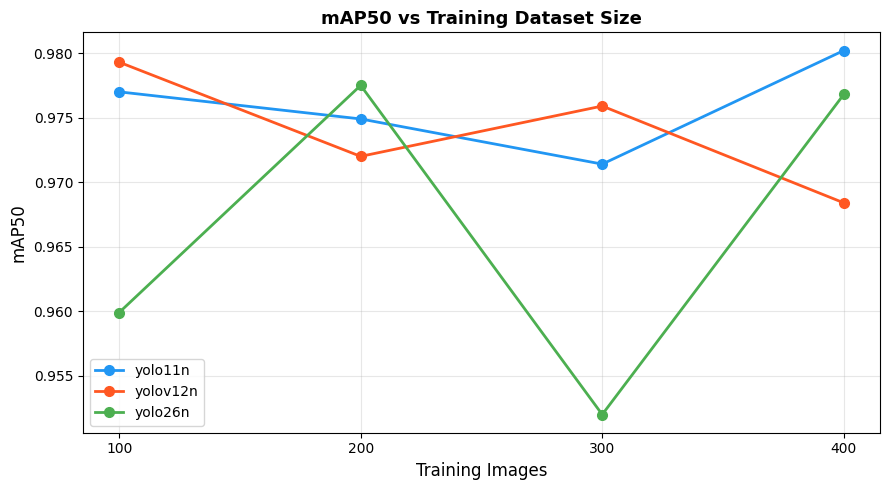

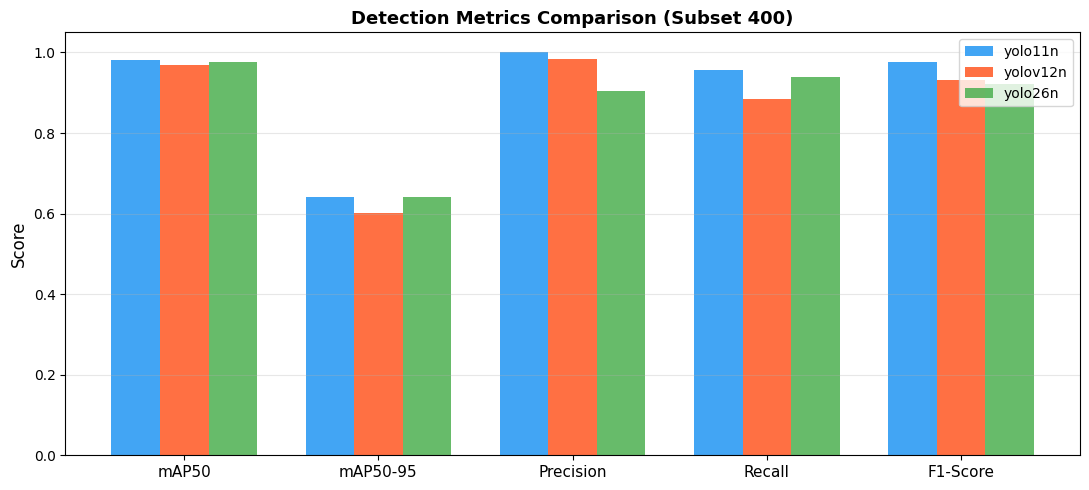

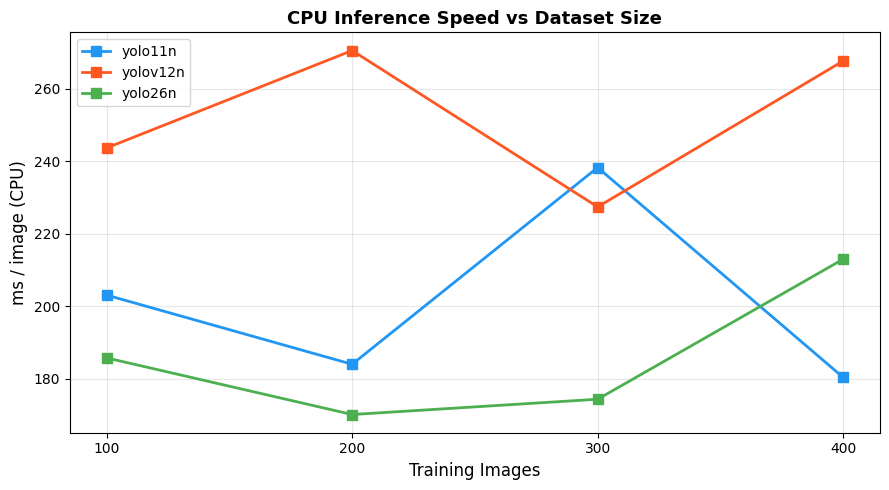

All 3 plots saved.
Backed up: inference_speed.csv
Backed up: results.csv
Backed up: plot_mAP50_scaling.png
Backed up: plot_inference_speed.png
Backed up: plot_metrics_subset400.png
Backed up weights: yolo11n_subset100_best.pt
Backed up weights: yolo11n_subset200_best.pt
Backed up weights: yolo11n_subset300_best.pt
Backed up weights: yolo11n_subset400_best.pt
Backed up weights: yolov12n_subset100_best.pt
Backed up weights: yolov12n_subset200_best.pt
Backed up weights: yolov12n_subset300_best.pt
Backed up weights: yolov12n_subset400_best.pt
Backed up weights: yolo26n_subset100_best.pt
Backed up weights: yolo26n_subset200_best.pt
Backed up weights: yolo26n_subset300_best.pt
Backed up weights: yolo26n_subset400_best.pt

All files backed up to Google Drive at /yolo_experiments


In [1]:
# =============================================================================
# YOLO11 vs YOLOv12 vs YOLO26 — License Plate Detection Experiments
# Author  : Aimran El Boumeshouli
# Course  : IM1312 Research Methods for Artificial Intelligence
# Institution: Open University of the Netherlands
#
# This script reproduces all 12 experimental conditions (3 models × 4 dataset
# sizes) following the 7-step procedure described in the report.
#
# ⚠️  Run on Google Colab with: Runtime → Change runtime type → T4 GPU
# =============================================================================


# ── Pre-flight: verify GPU and install dependencies ───────────────────────────
# (These setup steps are required before the 7 procedure steps begin.)

!nvidia-smi
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU found — change runtime type to T4')

!pip install ultralytics roboflow -q

import ultralytics
print(f'Ultralytics version: {ultralytics.__version__}')

# Mount Google Drive for backup (used in Step 7)
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted at /content/drive')


# =============================================================================
# STEP 1 — The dataset was downloaded from Roboflow Universe via the
#           Roboflow Python API.
# =============================================================================

from roboflow import Roboflow
from pathlib import Path

API_KEY = 'vaa2M7NswPFy9vZjjBk1'  # <-- replace with your Roboflow API key


rf      = Roboflow(api_key=API_KEY)
project = rf.workspace('lums-szkgm').project('dutch-license-plates')
dataset = project.version(4).download('yolov8')
print('Dataset downloaded successfully')

# Verify dataset structure
DATASET_PATH = Path('/content/Dutch-License-Plates-4')

train_imgs = (list((DATASET_PATH / 'train' / 'images').glob('*.jpg')) +
              list((DATASET_PATH / 'train' / 'images').glob('*.png')))
valid_imgs = (list((DATASET_PATH / 'valid' / 'images').glob('*.jpg')) +
              list((DATASET_PATH / 'valid' / 'images').glob('*.png')))
test_imgs  = (list((DATASET_PATH / 'test'  / 'images').glob('*.jpg')) +
              list((DATASET_PATH / 'test'  / 'images').glob('*.png')))

print(f'Train images : {len(train_imgs)}')
print(f'Valid images : {len(valid_imgs)}')
print(f'Test  images : {len(test_imgs)}')
print(f'Total        : {len(train_imgs) + len(valid_imgs) + len(test_imgs)}')

with open(DATASET_PATH / 'data.yaml') as f:
    print('\ndata.yaml contents (before fix):')
    print(f.read())

# Download YOLOv12n weights manually — not on the default Ultralytics server
import urllib.request

yolov12_path = Path('yolov12n.pt')
if yolov12_path.exists():
    print('yolov12n.pt already present')
else:
    print('Downloading yolov12n.pt from GitHub...')
    url = 'https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt'
    try:
        urllib.request.urlretrieve(url, 'yolov12n.pt')
        print('Downloaded yolov12n.pt successfully')
    except Exception as e:
        print(f'Primary URL failed: {e} — trying fallback...')
        fallback = 'https://huggingface.co/sunsmarterjie/yolov12/resolve/main/yolov12n.pt'
        urllib.request.urlretrieve(fallback, 'yolov12n.pt')
        print('Downloaded from fallback URL')

# Verify all 3 model weights are loadable
from ultralytics import YOLO

print('\nVerifying model weights...')
for name, weights in [('yolo11n', 'yolo11n.pt'),
                      ('yolov12n', 'yolov12n.pt'),
                      ('yolo26n', 'yolo26n.pt')]:
    try:
        YOLO(weights)
        print(f'  {name}: OK')
    except Exception as e:
        print(f'  {name}: FAILED — {e}')


# =============================================================================
# STEP 2 — data.yaml was updated: the class name was changed from LPBOX to
#           license-plate and absolute paths were set.
# =============================================================================

import yaml

yaml_path = DATASET_PATH / 'data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['names'] = ['license-plate']
data['nc']    = 1
data['train'] = str(DATASET_PATH / 'train' / 'images')
data['val']   = str(DATASET_PATH / 'valid' / 'images')
data['test']  = str(DATASET_PATH / 'test'  / 'images')

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print('data.yaml updated:')
with open(yaml_path) as f:
    print(f.read())


# =============================================================================
# STEP 3 — Four stratified training subsets were created (random.seed(42)),
#           each with its own data.yaml.
# =============================================================================

import shutil
import random

random.seed(42)  # ensures reproducibility across runs

train_images_dir = DATASET_PATH / 'train' / 'images'
train_labels_dir = DATASET_PATH / 'train' / 'labels'

all_images = sorted(
    list(train_images_dir.glob('*.jpg')) +
    list(train_images_dir.glob('*.png'))
)
print(f'Total training images available: {len(all_images)}')

random.shuffle(all_images)

SUBSET_SIZES  = [100, 200, 300, 400]
SUBSETS_ROOT  = Path('/content/subsets')

# Copy images and labels for each subset size
for size in SUBSET_SIZES:
    subset_imgs = all_images[:size]
    out_img = SUBSETS_ROOT / f'subset_{size}' / 'images'
    out_lbl = SUBSETS_ROOT / f'subset_{size}' / 'labels'
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)
    copied = 0
    for img_path in subset_imgs:
        shutil.copy(img_path, out_img / img_path.name)
        lbl_path = train_labels_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            shutil.copy(lbl_path, out_lbl / lbl_path.name)
            copied += 1
    print(f'Subset {size:>3}: {copied} image-label pairs copied')

# Create a dedicated data.yaml for each subset
for size in SUBSET_SIZES:
    subset_yaml = {
        'train': str(SUBSETS_ROOT / f'subset_{size}' / 'images'),
        'val':   str(DATASET_PATH / 'valid' / 'images'),
        'test':  str(DATASET_PATH / 'test'  / 'images'),
        'nc':    1,
        'names': ['license-plate'],
    }
    yaml_out = SUBSETS_ROOT / f'subset_{size}' / 'data.yaml'
    with open(yaml_out, 'w') as f:
        yaml.dump(subset_yaml, f, default_flow_style=False)
    print(f'data.yaml created for subset_{size}')

# Verify one sample yaml
with open(SUBSETS_ROOT / 'subset_100' / 'data.yaml') as f:
    print('\nSample (subset_100):')
    print(f.read())

print('All subsets created successfully')


# =============================================================================
# STEP 4 — All 12 models were trained for 50 epochs; completed runs were
#           detected via best.pt and skipped on re-execution.
# =============================================================================

import time

# Re-check YOLOv12n weights in case this step runs after a Colab reconnect
if not Path('yolov12n.pt').exists():
    print('yolov12n.pt missing — downloading now...')
    try:
        urllib.request.urlretrieve(
            'https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt',
            'yolov12n.pt'
        )
        print('yolov12n.pt downloaded')
    except Exception as e:
        print(f'Primary URL failed: {e} — trying fallback...')
        urllib.request.urlretrieve(
            'https://huggingface.co/sunsmarterjie/yolov12/resolve/main/yolov12n.pt',
            'yolov12n.pt'
        )
        print('yolov12n.pt downloaded from fallback')
else:
    print('yolov12n.pt already present')

MODELS = [
    ('yolo11n',  'yolo11n.pt'),
    ('yolov12n', 'yolov12n.pt'),
    ('yolo26n',  'yolo26n.pt'),
]

EXPERIMENTS_DIR = '/content/experiments'
completed = []
failed    = []
total_start = time.time()

for model_name, model_weights in MODELS:
    for size in SUBSET_SIZES:
        run_name  = f'{model_name}_subset{size}'
        yaml_path = str(SUBSETS_ROOT / f'subset_{size}' / 'data.yaml')
        run_dir   = Path(EXPERIMENTS_DIR) / run_name

        print(f'\n{"="*55}')
        print(f'  Training: {run_name}')
        print('='*55)

        # Skip already-completed runs (checkpoint logic for Colab reconnects)
        if (run_dir / 'weights' / 'best.pt').exists():
            print('  Already completed — skipping')
            completed.append(run_name)
            continue

        try:
            model     = YOLO(model_weights)
            run_start = time.time()
            model.train(
                data     = yaml_path,
                epochs   = 50,
                imgsz    = 640,
                batch    = 16,
                name     = run_name,
                project  = EXPERIMENTS_DIR,
                exist_ok = True,
                verbose  = True,
            )
            elapsed = (time.time() - run_start) / 60
            print(f'  Completed in {elapsed:.1f} min')
            completed.append(run_name)
        except Exception as e:
            print(f'  FAILED: {e}')
            failed.append(run_name)

total_elapsed = (time.time() - total_start) / 60
print(f'\nAll training done in {total_elapsed:.1f} min')
print(f'Completed : {len(completed)}/12')
if failed:
    print(f'Failed    : {failed}')


# =============================================================================
# STEP 5 — Each trained model was evaluated on the fixed test set and mAP50,
#           mAP50-95, precision, recall, and F1-score were recorded.
# =============================================================================

import pandas as pd

TEST_YAML   = str(DATASET_PATH / 'data.yaml')
results_log = []

for model_name, _ in MODELS:
    for size in SUBSET_SIZES:
        run_name = f'{model_name}_subset{size}'
        weights  = Path(EXPERIMENTS_DIR) / run_name / 'weights' / 'best.pt'

        if not weights.exists():
            print(f'SKIPPING {run_name} — weights not found')
            continue

        print(f'Evaluating {run_name}...')
        model   = YOLO(str(weights))
        metrics = model.val(data=TEST_YAML, split='test', verbose=False)

        p  = metrics.box.mp
        r  = metrics.box.mr
        f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

        results_log.append({
            'Model'      : model_name,
            'Subset Size': size,
            'mAP50'      : round(metrics.box.map50, 4),
            'mAP50-95'   : round(metrics.box.map,   4),
            'Precision'  : round(p,  4),
            'Recall'     : round(r,  4),
            'F1-Score'   : round(f1, 4),
        })
        print(f'  mAP50={metrics.box.map50:.4f}  P={p:.4f}  R={r:.4f}  F1={f1:.4f}')

results_df = pd.DataFrame(results_log)
print('\n=== FULL RESULTS ===')
print(results_df.to_string(index=False))

# Save detection results to CSV (also used in Step 7)
results_df.to_csv(Path(EXPERIMENTS_DIR) / 'results.csv', index=False)
print(f'Saved to {EXPERIMENTS_DIR}/results.csv')


# =============================================================================
# STEP 6 — CPU inference speed was measured on 20 test images per model
#           (with a warm-up run).
# =============================================================================

import glob

test_images = glob.glob(str(DATASET_PATH / 'test' / 'images' / '*.jpg'))[:20]
print(f'Running inference on {len(test_images)} images (CPU)...\n')

speed_log = []

for model_name, _ in MODELS:
    for size in SUBSET_SIZES:
        run_name = f'{model_name}_subset{size}'
        weights  = Path(EXPERIMENTS_DIR) / run_name / 'weights' / 'best.pt'

        if not weights.exists():
            print(f'SKIPPING {run_name} — weights not found')
            continue

        model = YOLO(str(weights))
        model.predict(test_images[:2], device='cpu', verbose=False)  # warm-up run

        start   = time.time()
        model.predict(test_images, device='cpu', verbose=False)
        elapsed = time.time() - start

        ms_per_image = (elapsed / len(test_images)) * 1000
        print(f'{run_name:<30} {ms_per_image:>8.1f} ms/image')
        speed_log.append({
            'Model'       : model_name,
            'Subset Size' : size,
            'ms_per_image': round(ms_per_image, 2),
        })

speed_df = pd.DataFrame(speed_log)

# Save speed results to CSV (also used in Step 7)
speed_df.to_csv(Path(EXPERIMENTS_DIR) / 'inference_speed.csv', index=False)
print(f'\nSaved to {EXPERIMENTS_DIR}/inference_speed.csv')


# =============================================================================
# STEP 7 — All results were saved to CSV and backed up to Google Drive.
# =============================================================================

import matplotlib.pyplot as plt

# --- Generate result plots before backup ---

df       = pd.read_csv(Path(EXPERIMENTS_DIR) / 'results.csv')
speed_df = pd.read_csv(Path(EXPERIMENTS_DIR) / 'inference_speed.csv')
models   = df['Model'].unique()
subsets  = sorted(df['Subset Size'].unique())
colors   = {'yolo11n': '#2196F3', 'yolov12n': '#FF5722', 'yolo26n': '#4CAF50'}

# Plot 1: mAP50 scaling curves (RQ2)
fig, ax = plt.subplots(figsize=(9, 5))
for m in models:
    sub = df[df['Model'] == m].sort_values('Subset Size')
    ax.plot(sub['Subset Size'], sub['mAP50'],
            marker='o', label=m, color=colors.get(m), linewidth=2, markersize=7)
ax.set_xlabel('Training Images', fontsize=12)
ax.set_ylabel('mAP50', fontsize=12)
ax.set_title('mAP50 vs Training Dataset Size', fontsize=13, fontweight='bold')
ax.set_xticks(subsets)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(Path(EXPERIMENTS_DIR) / 'plot_mAP50_scaling.png', dpi=150)
plt.show()

# Plot 2: All metrics at subset 400 (RQ1)
metric_cols = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1-Score']
df400 = df[df['Subset Size'] == 400]
x     = range(len(metric_cols))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(models):
    row = df400[df400['Model'] == m]
    if len(row) == 0:
        continue
    vals = [row.iloc[0][met] for met in metric_cols]
    ax.bar([xi + i * width for xi in x], vals, width,
           label=m, color=colors.get(m), alpha=0.85)
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Detection Metrics Comparison (Subset 400)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(Path(EXPERIMENTS_DIR) / 'plot_metrics_subset400.png', dpi=150)
plt.show()

# Plot 3: CPU inference speed (RQ3)
fig, ax = plt.subplots(figsize=(9, 5))
for m in models:
    sub = speed_df[speed_df['Model'] == m].sort_values('Subset Size')
    ax.plot(sub['Subset Size'], sub['ms_per_image'],
            marker='s', label=m, color=colors.get(m), linewidth=2, markersize=7)
ax.set_xlabel('Training Images', fontsize=12)
ax.set_ylabel('ms / image (CPU)', fontsize=12)
ax.set_title('CPU Inference Speed vs Dataset Size', fontsize=13, fontweight='bold')
ax.set_xticks(subsets)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(Path(EXPERIMENTS_DIR) / 'plot_inference_speed.png', dpi=150)
plt.show()

print('All 3 plots saved.')

# --- Back up CSVs, plots, and model weights to Google Drive ---
drive_backup = Path('/content/drive/MyDrive/yolo_experiments')
drive_backup.mkdir(parents=True, exist_ok=True)

for f in Path(EXPERIMENTS_DIR).glob('*.csv'):
    shutil.copy(f, drive_backup / f.name)
    print(f'Backed up: {f.name}')

for f in Path(EXPERIMENTS_DIR).glob('*.png'):
    shutil.copy(f, drive_backup / f.name)
    print(f'Backed up: {f.name}')

weights_backup = drive_backup / 'weights'
weights_backup.mkdir(exist_ok=True)

for model_name, _ in MODELS:
    for size in SUBSET_SIZES:
        run_name = f'{model_name}_subset{size}'
        best_pt  = Path(EXPERIMENTS_DIR) / run_name / 'weights' / 'best.pt'
        if best_pt.exists():
            shutil.copy(best_pt, weights_backup / f'{run_name}_best.pt')
            print(f'Backed up weights: {run_name}_best.pt')

print('\nAll files backed up to Google Drive at /yolo_experiments')
